# TMDB - Box Office Prediction

Table of Contents

- [1. Data Loading and Overview](#1-data-loading-and-overview)
- [2. EDA - Exploratory Data Analysis](#2-eda---exploratory-data-analysis)
  - [2.1 Revenue](#21-revenue)
  - [2.2 Release Date](#22-release-date)
  - [2.3 Budget](#23-budget)
  - [2.4 Genres](#24-genres)
  - [2.5 Homepage](#25-homepage)
  - [2.6 Production Companies](#26-production-companies)
  - [2.7 Production Countries](#27-production-countries)
  - [2.8 Spoken Languages](#28-spoken-languages)
  - [2.9 Tagline](#29-tagline)
  - [2.10 Keywords](#210-keywords)
  - [2.11 Cast](#211-cast)
  - [2.12 Crew](#212-crew)
  - [2.13 Popularity](#213-popularity)
  - [2.14 Belongs To Collection](#214-belongs-to-collection)
  - [2.15 Original Language](#215-original-language)


## 1. Data Loading and Overview

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from utils import fix_dataset
from wordcloud import WordCloud


%matplotlib inline
random_state = 42
np.random.seed(random_state)

In [2]:
train = pd.read_csv('../data/train.csv', index_col='id')
print(f"Shape of the train set: {train.shape}")

Shape of the train set: (3000, 22)


In [3]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 1 to 3000
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   belongs_to_collection  604 non-null    str    
 1   budget                 3000 non-null   int64  
 2   genres                 2993 non-null   str    
 3   homepage               946 non-null    str    
 4   imdb_id                3000 non-null   str    
 5   original_language      3000 non-null   str    
 6   original_title         3000 non-null   str    
 7   overview               2992 non-null   str    
 8   popularity             3000 non-null   float64
 9   poster_path            2999 non-null   str    
 10  production_companies   2844 non-null   str    
 11  production_countries   2945 non-null   str    
 12  release_date           3000 non-null   str    
 13  runtime                2998 non-null   float64
 14  spoken_languages       2980 non-null   str    
 15  status         

The dataset has columns with null values and many of them contain text data. We will need to handle these null values and possibly extract features from the text data later on.

In [4]:
train.head()

,belongs_to_collection,budget,genres,homepage,imdb_id,original_language,original_title,overview,popularity,poster_path,...,release_date,runtime,spoken_languages,status,tagline,title,Keywords,cast,crew,revenue
id,,,,,,,,,,,,,,,,,,,,,
1,"[{'id': 313576, 'name': 'Hot Tub Time Machine ...",14000000,"[{'id': 35, 'name': 'Comedy'}]",NaN,tt2637294,en,Hot Tub Time Machine 2,"When Lou, who has become the ""father of the In...",6.575393,/tQtWuwvMf0hCc2QR2tkolwl7c3c.jpg,...,2/20/15,93.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The Laws of Space and Time are About to be Vio...,Hot Tub Time Machine 2,"[{'id': 4379, 'name': 'time travel'}, {'id': 9...","[{'cast_id': 4, 'character': 'Lou', 'credit_id...","[{'credit_id': '59ac067c92514107af02c8c8', 'de...",12314651
2,"[{'id': 107674, 'name': 'The Princess Diaries ...",40000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,tt0368933,en,The Princess Diaries 2: Royal Engagement,Mia Thermopolis is now a college graduate and ...,8.248895,/w9Z7A0GHEhIp7etpj0vyKOeU1Wx.jpg,...,8/6/04,113.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,It can take a lifetime to find true love; she'...,The Princess Diaries 2: Royal Engagement,"[{'id': 2505, 'name': 'coronation'}, {'id': 42...","[{'cast_id': 1, 'character': 'Mia Thermopolis'...","[{'credit_id': '52fe43fe9251416c7502563d', 'de...",95149435
3,NaN,3300000,"[{'id': 18, 'name': 'Drama'}]",http://sonyclassics.com/whiplash/,tt2582802,en,Whiplash,"Under the direction of a ruthless instructor, ...",64.299990,/lIv1QinFqz4dlp5U4lQ6HaiskOZ.jpg,...,10/10/14,105.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The road to greatness can take you to the edge.,Whiplash,"[{'id': 1416, 'name': 'jazz'}, {'id': 1523, 'n...","[{'cast_id': 5, 'character': 'Andrew Neimann',...","[{'credit_id': '54d5356ec3a3683ba0000039', 'de...",13092000
4,NaN,1200000,"[{'id': 53, 'name': 'Thriller'}, {'id': 18, 'n...",http://kahaanithefilm.com/,tt1821480,hi,Kahaani,Vidya Bagchi (Vidya Balan) arrives in Kolkata ...,3.174936,/aTXRaPrWSinhcmCrcfJK17urp3F.jpg,...,3/9/12,122.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,NaN,Kahaani,"[{'id': 10092, 'name': 'mystery'}, {'id': 1054...","[{'cast_id': 1, 'character': 'Vidya Bagchi', '...","[{'credit_id': '52fe48779251416c9108d6eb', 'de...",16000000
5,NaN,0,"[{'id': 28, 'name': 'Action'}, {'id': 53, 'nam...",NaN,tt1380152,ko,마린보이,Marine Boy is the story of a former national s...,1.148070,/m22s7zvkVFDU9ir56PiiqIEWFdT.jpg,...,2/5/09,118.0,"[{'iso_639_1': 'ko', 'name': '한국어/조선말'}]",Released,NaN,Marine Boy,NaN,"[{'cast_id': 3, 'character': 'Chun-soo', 'cred...","[{'credit_id': '52fe464b9251416c75073b43', 'de...",3923970


As we can see, there are some columns that contain lists of dictionaries, so we'll need to extract the needed information from those ones.

Also, the Release Dates are in the mm/dd/yy format, but the dataset contains both movies released before and after 2000. That said, we'll convert the dates into mm/dd/yyyy format, to handle better the release years. Note that the competition started in 2019, so we can consider that there are no movies released later than this year.

In [5]:
train = fix_dataset(train)

display(train.head())

,belongs_to_collection,budget,genres,homepage,imdb_id,original_language,original_title,overview,popularity,poster_path,...,runtime,spoken_languages,status,tagline,title,Keywords,cast,crew,revenue,director
id,,,,,,,,,,,,,,,,,,,,,
1,[Hot Tub Time Machine Collection],14000000,[Comedy],NaN,tt2637294,en,Hot Tub Time Machine 2,"When Lou, who has become the ""father of the In...",6.575393,/tQtWuwvMf0hCc2QR2tkolwl7c3c.jpg,...,93.0,[en],Released,The Laws of Space and Time are About to be Vio...,Hot Tub Time Machine 2,"[time travel, sequel, hot tub, duringcreditsst...","[Rob Corddry, Craig Robinson, Clark Duke, Adam...","[Kelly Cantley, Steve Pink, Josh Heald, Josh H...",12314651,Steve Pink
2,[The Princess Diaries Collection],40000000,"[Comedy, Drama, Family, Romance]",NaN,tt0368933,en,The Princess Diaries 2: Royal Engagement,Mia Thermopolis is now a college graduate and ...,8.248895,/w9Z7A0GHEhIp7etpj0vyKOeU1Wx.jpg,...,113.0,[en],Released,It can take a lifetime to find true love; she'...,The Princess Diaries 2: Royal Engagement,"[coronation, duty, marriage, falling in love]","[Anne Hathaway, Julie Andrews, H√©ctor Elizond...","[Garry Marshall, Charles Minsky, John Debney, ...",95149435,Garry Marshall
3,[],3300000,[Drama],http://sonyclassics.com/whiplash/,tt2582802,en,Whiplash,"Under the direction of a ruthless instructor, ...",64.299990,/lIv1QinFqz4dlp5U4lQ6HaiskOZ.jpg,...,105.0,[en],Released,The road to greatness can take you to the edge.,Whiplash,"[jazz, obsession, conservatory, music teacher,...","[Miles Teller, J.K. Simmons, Melissa Benoist, ...","[Terri Taylor, Richard Henderson, Jeffrey Stot...",13092000,Damien Chazelle
4,[],1200000,"[Thriller, Drama]",http://kahaanithefilm.com/,tt1821480,hi,Kahaani,Vidya Bagchi (Vidya Balan) arrives in Kolkata ...,3.174936,/aTXRaPrWSinhcmCrcfJK17urp3F.jpg,...,122.0,"[en, hi]",Released,NaN,Kahaani,"[mystery, bollywood, police corruption, crime,...","[Vidya Balan, Nawazuddin Siddiqui, Parambrata ...","[Sujoy Ghosh, Sujoy Ghosh, Sujoy Ghosh]",16000000,Sujoy Ghosh
5,[],0,"[Action, Thriller]",NaN,tt1380152,ko,마린보이,Marine Boy is the story of a former national s...,1.148070,/m22s7zvkVFDU9ir56PiiqIEWFdT.jpg,...,118.0,[ko],Released,NaN,Marine Boy,[],"[Kim Kang-woo, Jo Jae-hyeon, Park Si-yeon, Kim...","[Jong-seok Yoon, Jong-seok Yoon]",3923970,Jong-seok Yoon


## 2. EDA - Exploratory Data Analysis

In [6]:
# Utility functions for plotting

def display_distributions(df, column):
    color = sns.color_palette("viridis", 3)

    plt.figure(figsize=(20, 10))
    plt.subplot(1, 3, 1)
    sns.boxplot(x=df[column], color=color[0])
    plt.title(f'Boxplot of {column}')
    plt.subplot(1, 3, 2)
    sns.histplot(df[column], bins=50, kde=True, color=color[1])
    plt.title(f'Distribution of {column}')
    plt.subplot(1, 3, 3)
    sns.histplot(df[f'log_{column}'], bins=50, kde=True, color=color[2])
    plt.title(f'Distribution of log {column}')
    
    plt.tight_layout()
    plt.show()

def compare_feature_with_revenue(df, column):
    palette = sns.color_palette("viridis", 5)

    plt.figure(figsize=(20, 10))
    plt.subplot(1, 3, 1)
    sns.boxplot(x=df[column], color=palette[0])
    plt.title(f'Boxplot of {column}')
    plt.subplot(1, 3, 2)
    sns.regplot(
        x=column, 
        y='revenue', 
        data=df,
        scatter_kws={'alpha': 0.5, 'color': palette[2]},
        line_kws={'color': palette[1]}
    )
    plt.title(f'{column} vs revenue')
    plt.subplot(1, 3, 3)
    sns.regplot(
        x=np.log1p(df[column]), 
        y=df['log_revenue'],
        scatter_kws={'alpha': 0.5, 'color': palette[3]},
        line_kws={'color': palette[4]}
    )
    plt.title(f'Log {column} vs Log revenue')
    
    plt.tight_layout()
    plt.show()

def display_feature_revenue_catplot(df, column):
    sns.catplot(
        x=df[column].notna().astype(int), 
        y=df['revenue'],
        palette='viridis',
        hue=df[column].notna().astype(int),
        legend=False
    )
    plt.title(f'Revenue distribution by {column} presence')
    plt.xticks([0, 1], [f'No {column}', f'Has {column}'])
    plt.xlabel(f'{column} presence')
    plt.ylabel('Revenue')
    plt.show()

def display_multilabels_feature_distribution(df, column, limit, title):
    labels = df[column].explode().value_counts().reset_index()
    print(f"Number of distinct {title}: {len(labels)}")

    plt.figure(figsize = (10, 8))
    sns.barplot(
        x='count',
        y=column,
        data=labels.head(limit),
        palette='viridis',
        hue=column,
        legend=False
    )
    plt.title(f'Top {limit} {title}')
    plt.xlabel(f'{title}')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

def display_wordcloud(df, column, title):
    counts = df[column].explode().value_counts().reset_index()

    plt.imshow(WordCloud(
        width=800,
        height=400,
        background_color='white',
        colormap='viridis',
        max_words=100
    ).generate_from_frequencies(
        dict(zip(counts[column], counts['count']))
    ), interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Word Cloud of {title}')

### 2.1 Revenue

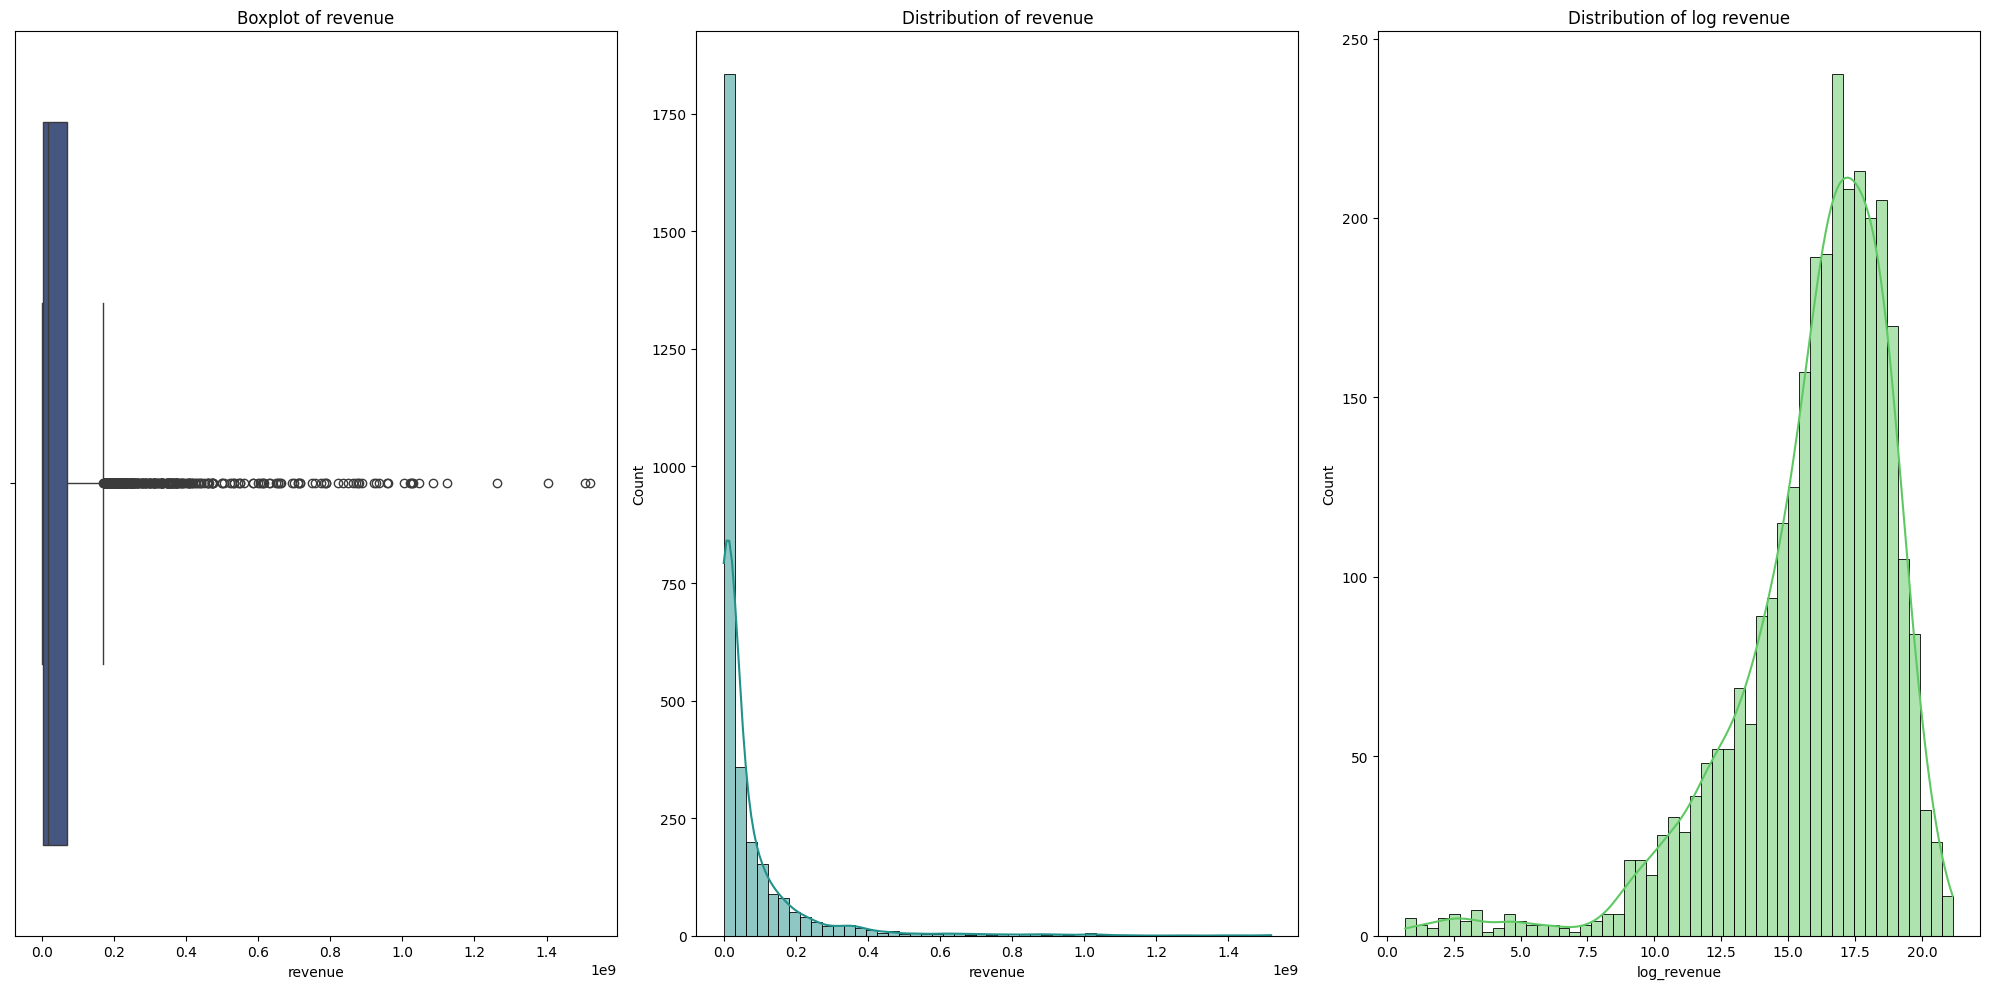

In [7]:
train['log_revenue'] = np.log1p(train['revenue'])

# Plots of the revenue distribution
display_distributions(train, 'revenue')

The boxplot of revenue shows that there are some outliers in the data, which is expected in a dataset like this. The histogram of revenue is right-skewed, indicating that most movies have low revenue, while a few have very high revenue. The histogram of log revenue is more normally distributed, which suggests that applying a log transformation to the target variable may help improve the performance of our models.

### 2.2 Release Date

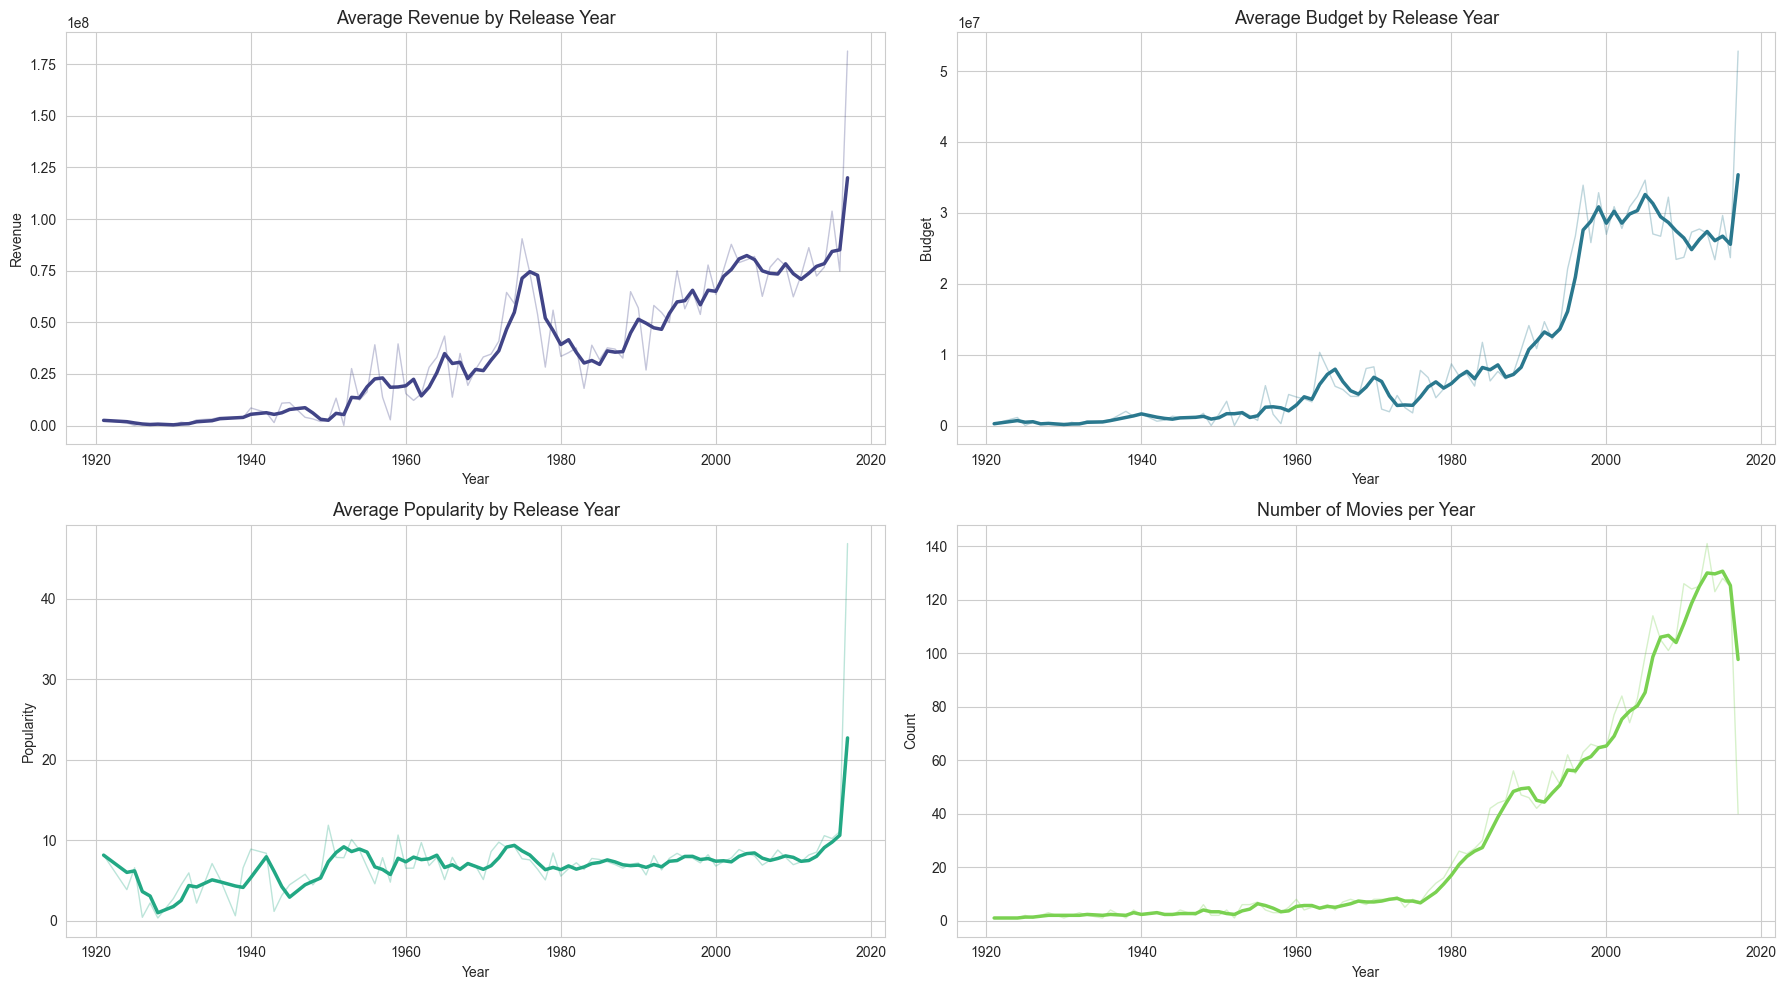

In [8]:
sns.set_style("whitegrid")
release_year = pd.to_datetime(train['release_date'], errors='coerce').dt.year
palette = sns.color_palette("viridis", 4)
release_year_plots = [
    {
        'data': train.groupby(release_year)['revenue'].mean().sort_index(),
        'color': palette[0],
        'title': 'Average Revenue by Release Year',
        'ylabel': 'Revenue'
    },
    {
        'data': train.groupby(release_year)['budget'].mean().sort_index(),
        'color': palette[1],
        'title': 'Average Budget by Release Year',
        'ylabel': 'Budget'
    },
    {
        'data': train.groupby(release_year)['popularity'].mean().sort_index(),
        'color': palette[2],
        'title': 'Average Popularity by Release Year',
        'ylabel': 'Popularity'
    },
    {
        'data': train.groupby(release_year).size().sort_index(),
        'color': palette[3],
        'title': 'Number of Movies per Year',
        'ylabel': 'Count'
    }
]

plt.figure(figsize=(18, 10))

for i, plot in enumerate(release_year_plots, 1):
    plt.subplot(2, 2, i)
    
    data = plot['data']
    smooth = data.rolling(window=3, min_periods=1).mean()
    
    sns.lineplot(x=data.index, y=data.values, color=plot['color'], alpha=0.3, linewidth=1)
    sns.lineplot(x=smooth.index, y=smooth.values, color=plot['color'], linewidth=2.5)
    
    plt.title(plot['title'], fontsize=13)
    plt.xlabel('Year')
    plt.ylabel(plot['ylabel'])

plt.tight_layout()
plt.show()

- **Revenue by Release Year**: Average revenue generally increases over time, with noticeable fluctuations and a sharp peak in the most recent years. This suggests that movies tend to generate higher revenues in more recent periods.
- **Budget by Release Year**: Movie budgets show a clear upward trend, especially from the 1990s onward, indicating that film production has become increasingly expensive over time.
- **Popularity by Release Year**: Popularity remains relatively stable for many decades but rises sharply in the most recent years, likely reflecting changes in how popularity is measured or the growing influence of digital platforms.
- **Movies Count per Release Year**: The number of movies released each year steadily increases, particularly after the 1980s, suggesting significant growth in film production over time.

### 2.3 Budget

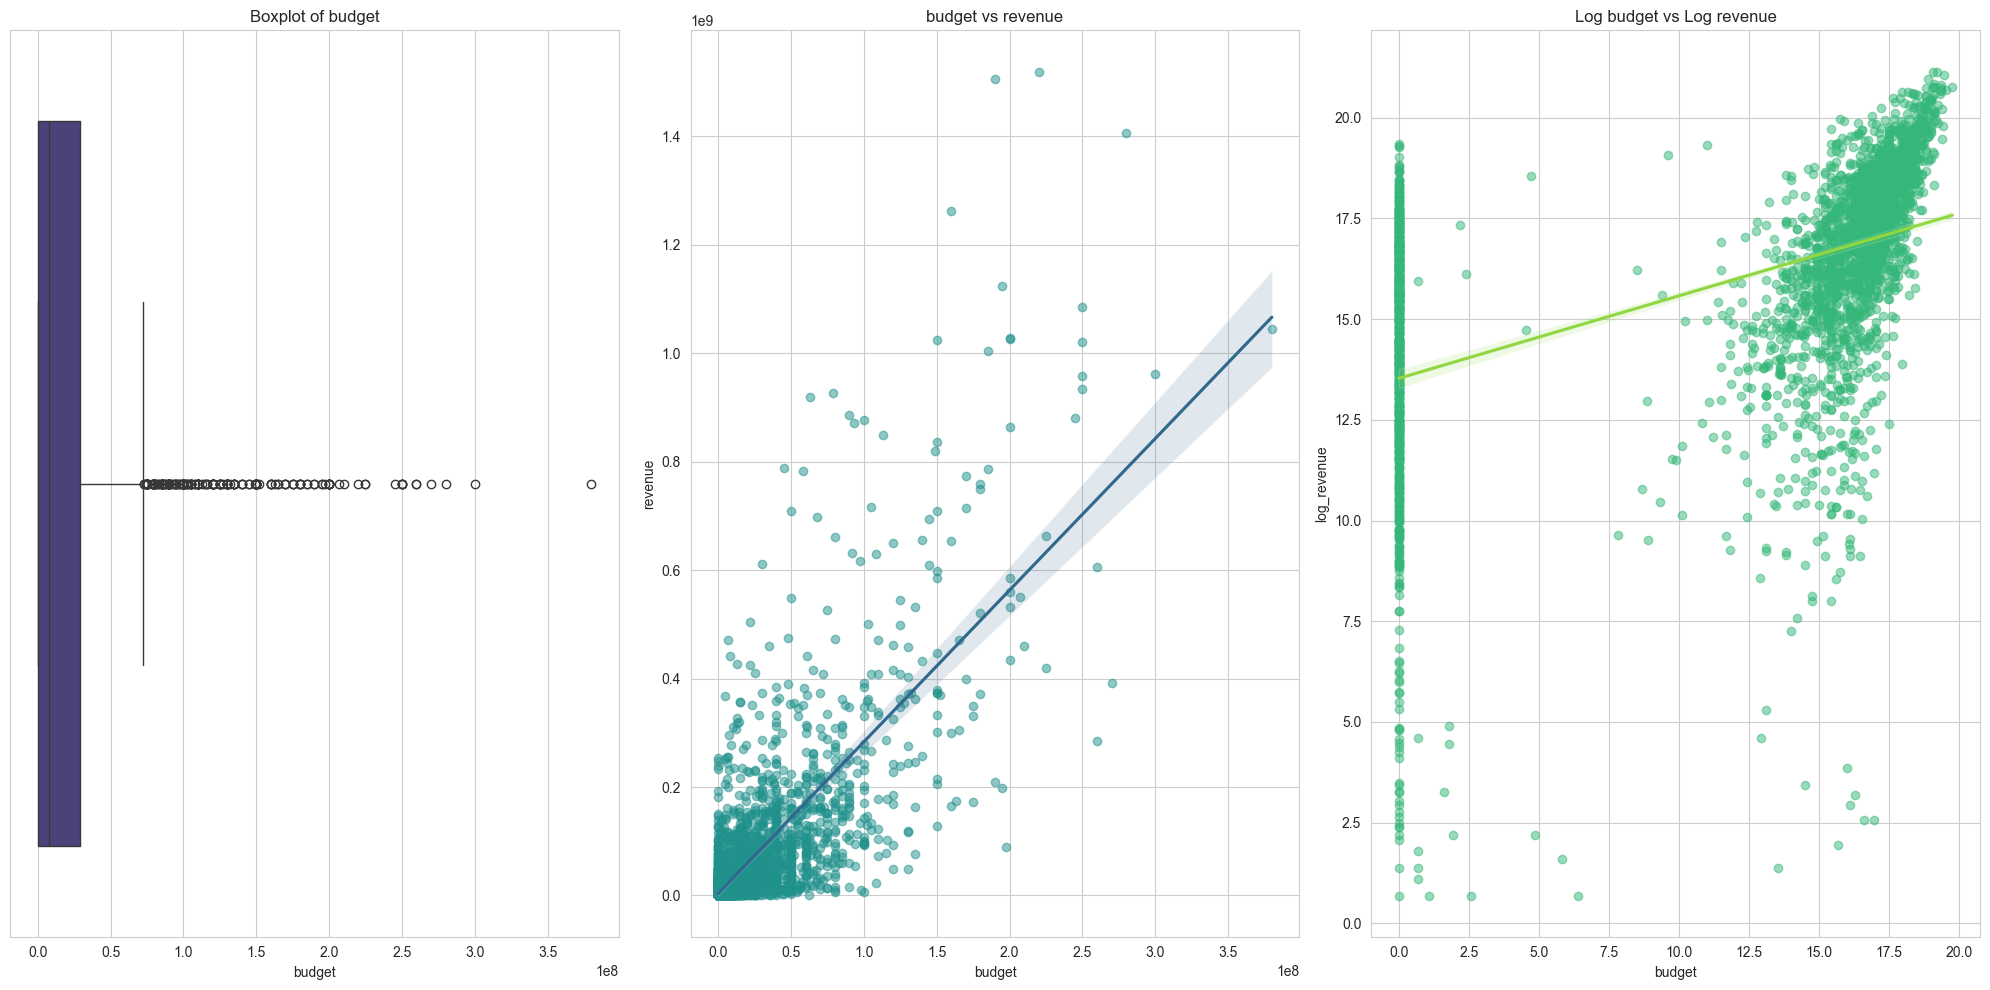

In [9]:
# Plots of the Budget distribution for train set
compare_feature_with_revenue(train, 'budget')

- **Boxplot of Budget**: The budget distribution is highly right-skewed, with most movies having relatively low budgets and several extreme outliers corresponding to very expensive productions.
- **Budget vs Revenue**: There is a positive relationship between budget and revenue: higher-budget movies tend to generate higher revenues, although the variance is large, indicating that high investment does not guarantee high revenue.
- **Log Budget vs Log Revenue**: After applying the logarithmic transformation, the relationship becomes more linear and clearer, suggesting that budget is a meaningful predictor of revenue and that the log transformation helps stabilize the variance.

### 2.4 Genres

Number of distinct Genres: 20


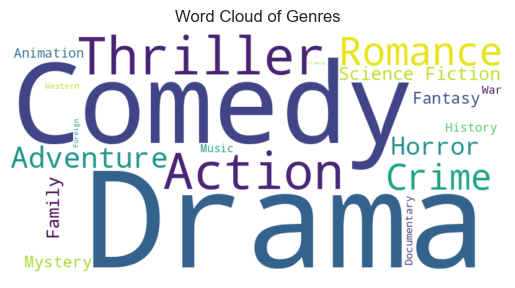

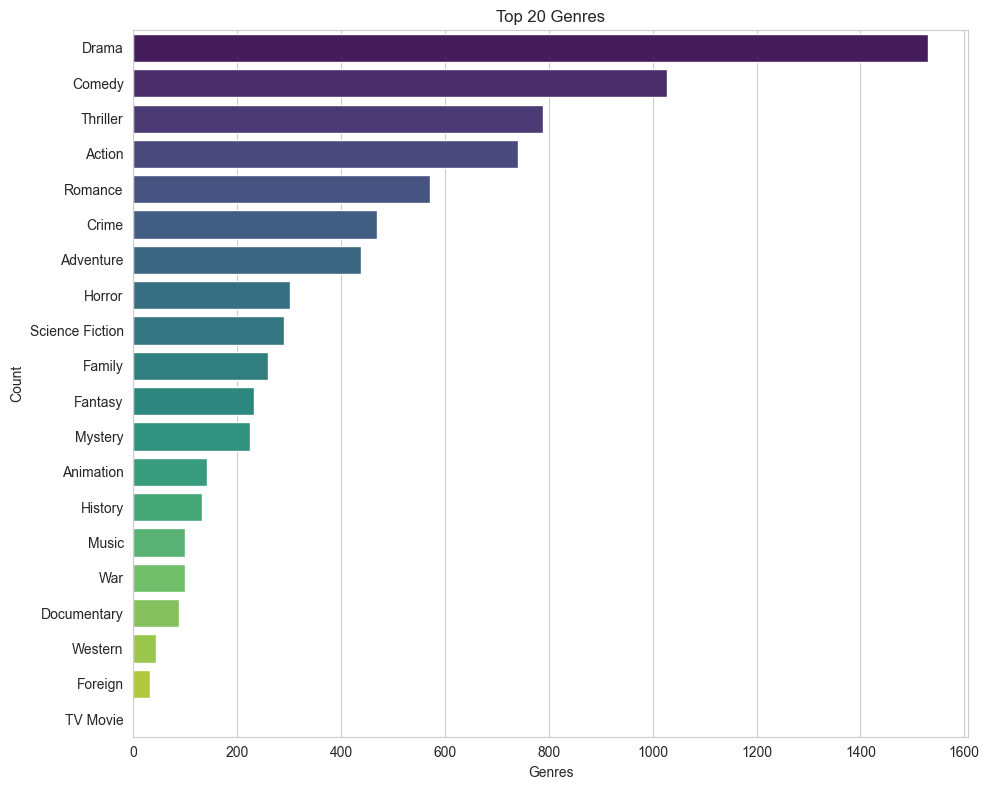

In [10]:
display_wordcloud(train, 'genres', 'Genres')
display_multilabels_feature_distribution(train, 'genres', 20, 'Genres')

The distribution of genres is clearly skewed, with Drama dominating by a large margin, followed by Comedy, Thriller, and Action. Although the distribution is imbalanced, the total number of genres is relatively small, so it is still feasible to consider all of them in the analysis. However, special attention should be paid to less frequent genres, as they may have limited statistical significance.

### 2.5 Homepage

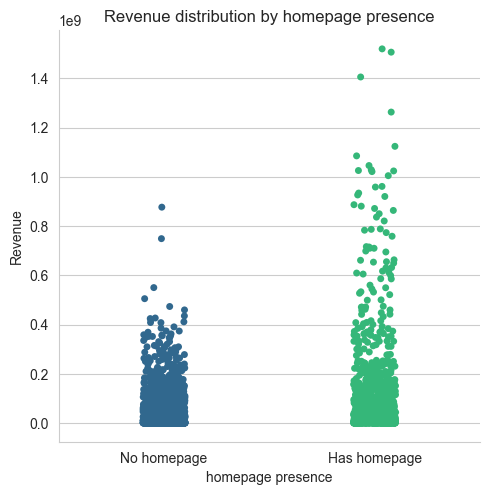

In [11]:
display_feature_revenue_catplot(train, 'homepage')

The plot shows that movies with a homepage tend to generate higher revenues compared to those without one. Films without a homepage are mostly concentrated at lower revenue levels, while movies with a homepage exhibit a wider distribution and include many of the highest-grossing titles. This suggests that the presence of a homepage may be associated with larger productions or stronger marketing efforts.

### 2.6 Production Companies

Number of distinct Production Companies: 3695


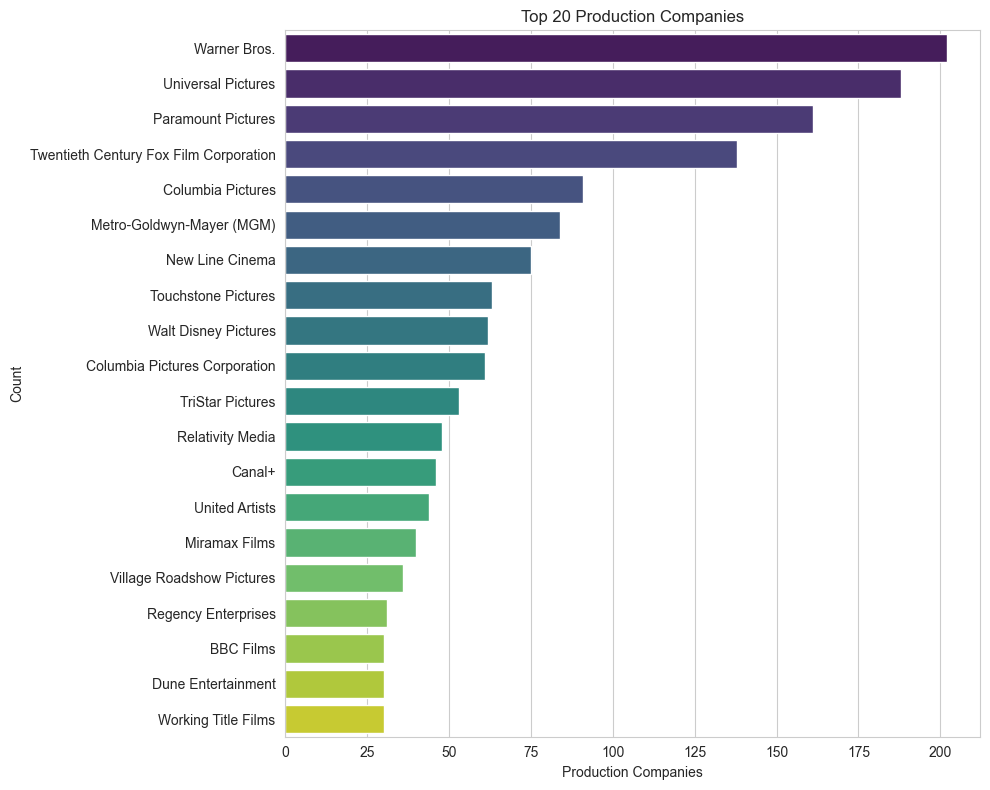

In [12]:
display_multilabels_feature_distribution(train, 'production_companies', 20, 'Production Companies')

The distribution of production companies is highly skewed: a small number of major studios appear frequently, while most companies occur only a few times. This confirms that the feature has very high cardinality and suggests that retaining only the most frequent companies is a reasonable strategy to reduce sparsity and improve generalization.

### 2.7 Production Countries

Number of distinct Production Countries: 74


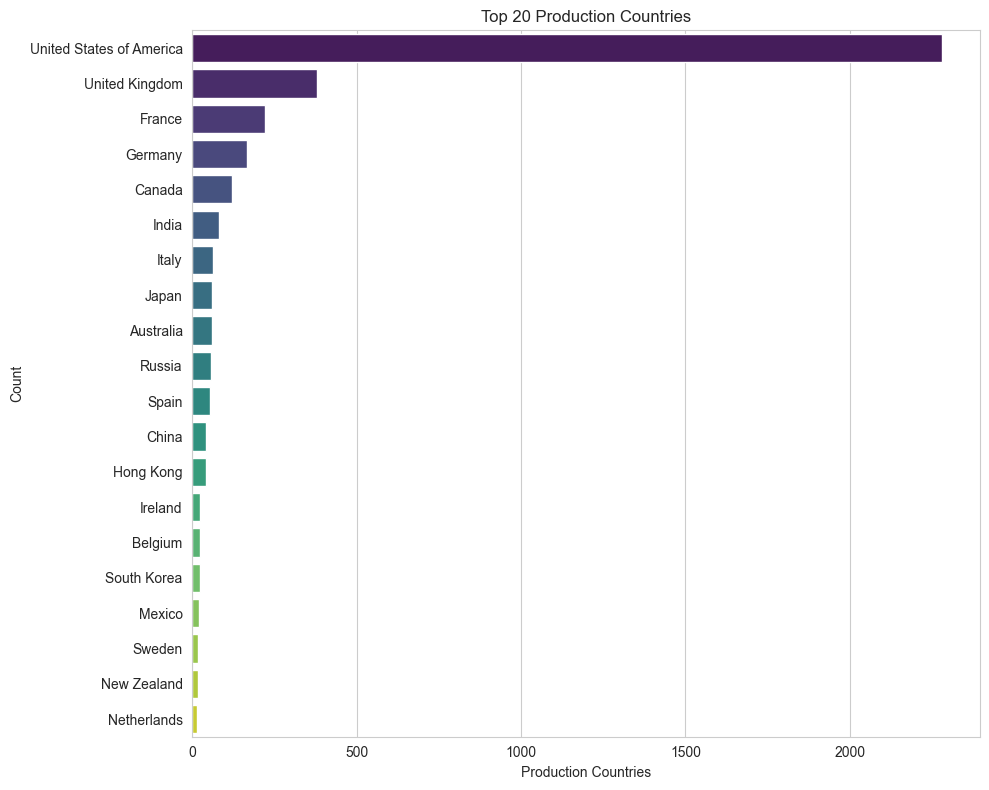

In [13]:
display_multilabels_feature_distribution(train, 'production_countries', 20, 'Production Countries')

As shown in the plot, the vast majority of films were produced in the United States, while many other production countries appear only once in the dataset. To mitigate overfitting and reduce sparsity, it is reasonable to retain only countries with a sufficient number of observations (e.g., more than 30 films)

### 2.8 Spoken Languages

Number of distinct Spoken Languages: 79


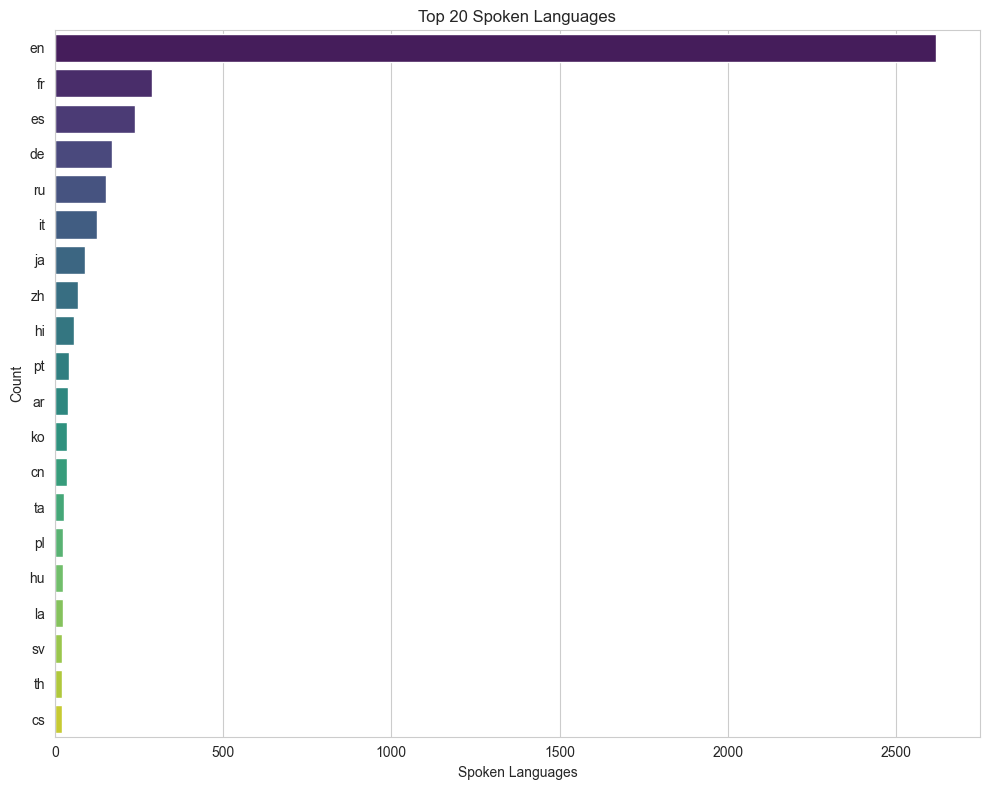

In [14]:
display_multilabels_feature_distribution(train, 'spoken_languages', 20, 'Spoken Languages')

The distribution of spoken languages is highly imbalanced, with English dominating the dataset by a large margin. Other languages such as French, Spanish, German, and Russian appear much less frequently, while languages like Italian, Japanese, Chinese, and Hindi have relatively few occurrences. In this case, it could be useful to consider only the languages that appear at least 50 times, in order to reduce the impact of underrepresented ones.

### 2.9 Tagline

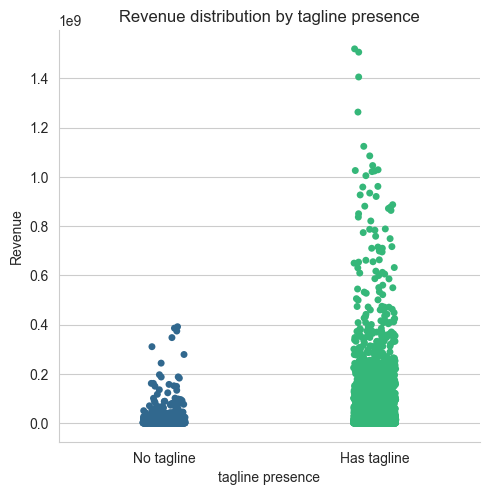

In [15]:
display_feature_revenue_catplot(train, 'tagline')

The plot shows that movies with a tagline tend to achieve higher revenues compared to those without one. Films without a tagline are mostly concentrated at lower revenue values, while movies with a tagline display a wider spread and include many high-revenue outliers. This suggests that the presence of a tagline may be associated with stronger promotion or higher-budget productions.

### 2.10 Keywords

Number of distinct Keywords: 7400


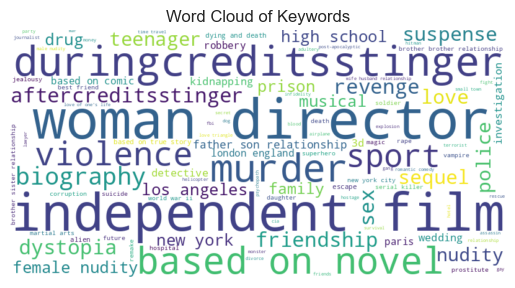

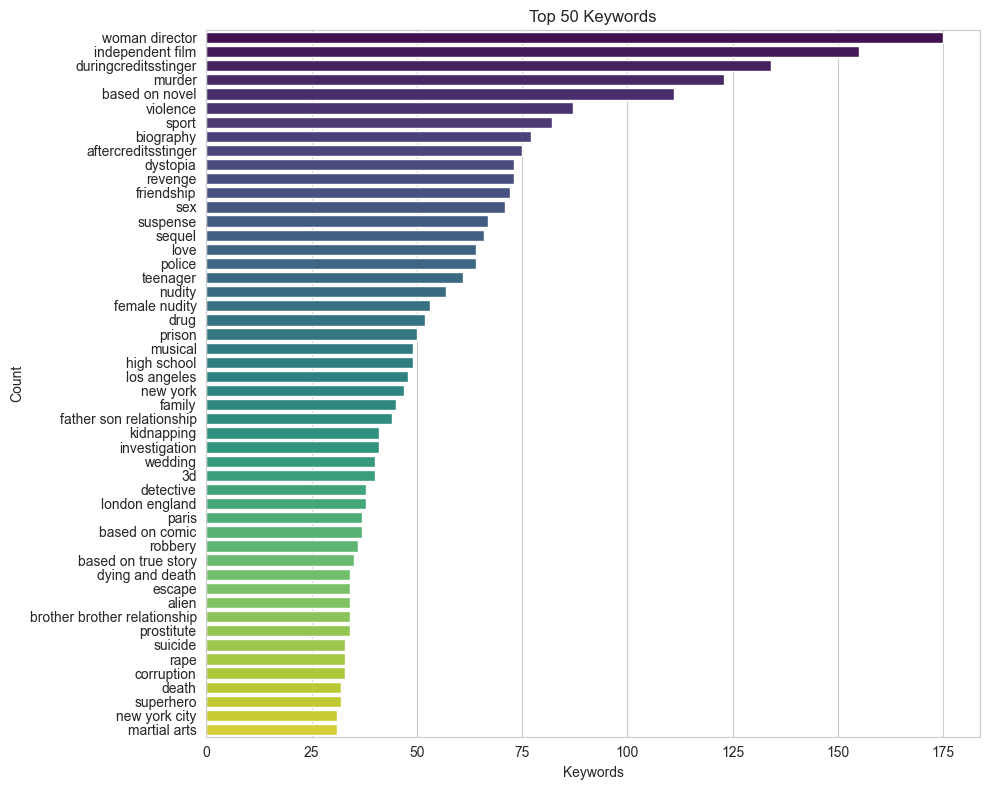

In [16]:
display_wordcloud(train, 'Keywords', 'Keywords')
display_multilabels_feature_distribution(train, 'Keywords', 50, 'Keywords')

The keyword distribution is highly skewed, with a few terms such as woman director, independent film, and murder appearing very frequently, while most others occur much less often. This reflects a classic long-tail distribution, where a small subset of keywords dominates the dataset. Considering that there are around 7,400 unique keywords, it is reasonable to filter and focus only on the most frequent ones.

### 2.11 Cast

Number of distinct Cast Members: 38588


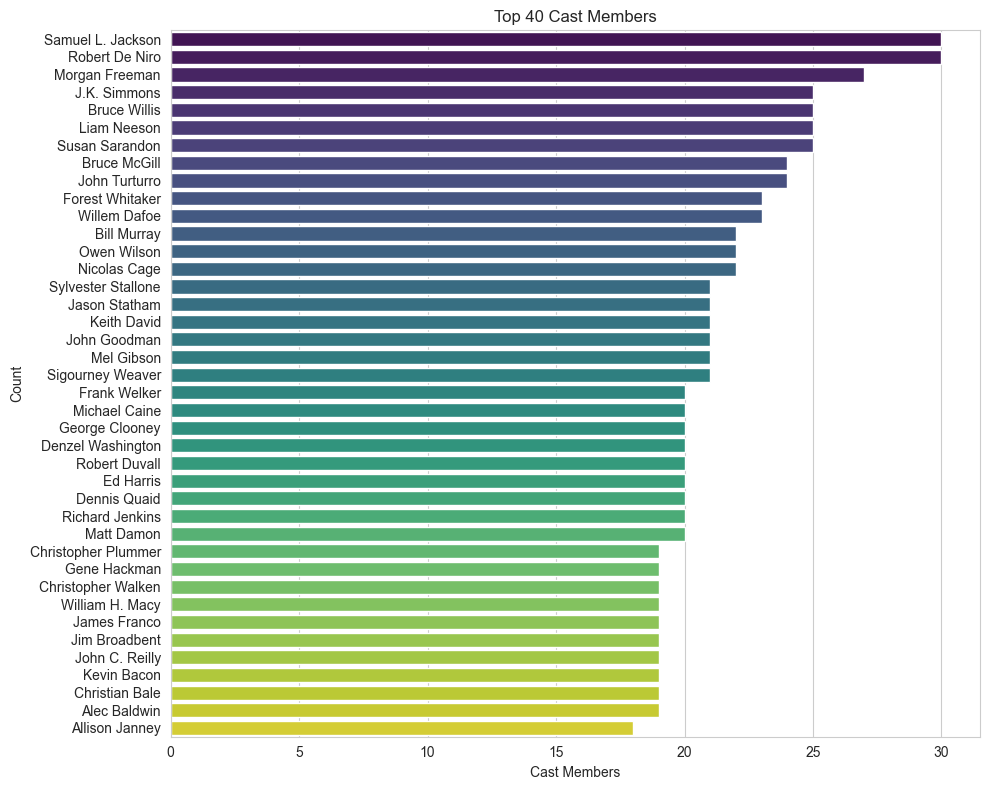

In [17]:
display_multilabels_feature_distribution(train, 'cast', 40, 'Cast Members')

Due to the huge amount of cast members, it is reasonable to focus on the most prominent actors. Well-known cast members are more likely to have a stronger impact on a movie’s success, as their presence can attract a larger audience and potentially lead to higher revenue.

### 2.12 Crew

Number of distinct Directors: 1857


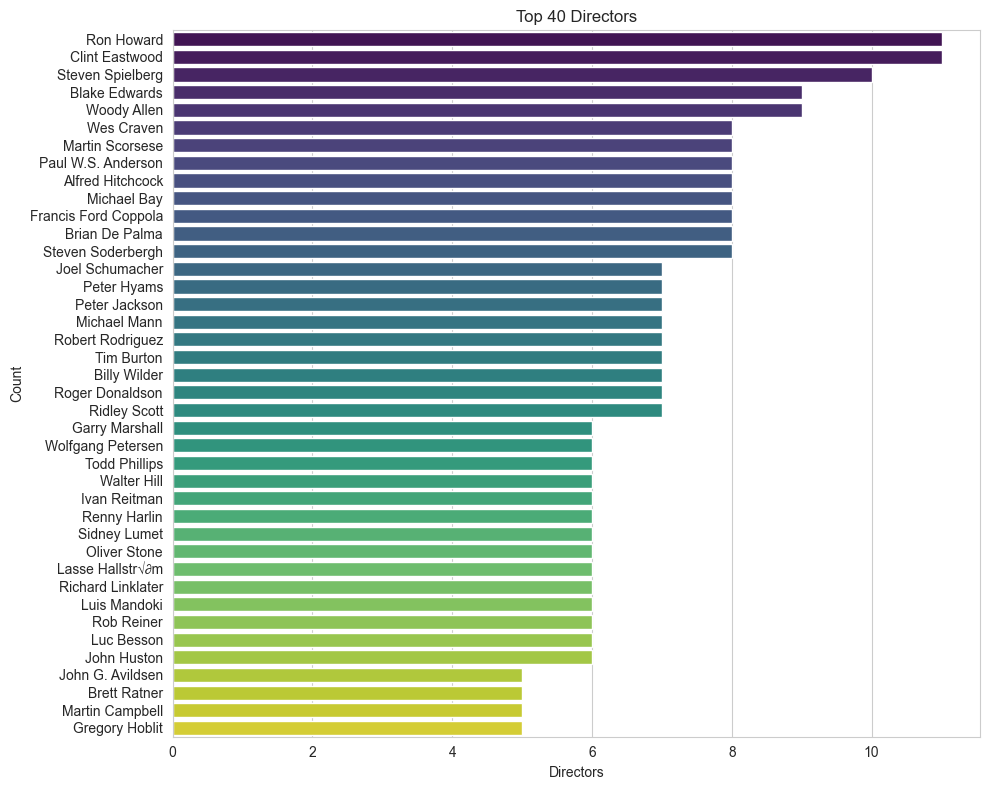

In [18]:
display_multilabels_feature_distribution(train, 'director', 40, 'Directors')

Given that there are 1857 unique directors, this indicates a high level of sparsity in this feature. From a predictive perspective, it is reasonable to focus on the most frequent or well-established directors. Renowned directors are more likely to influence a film’s commercial success due to their reputation, audience following, and production scale. Therefore, filtering or encoding only the most prominent directors can help reduce dimensionality and improve the model’s ability to capture meaningful patterns related to revenue.

### 2.13 Popularity

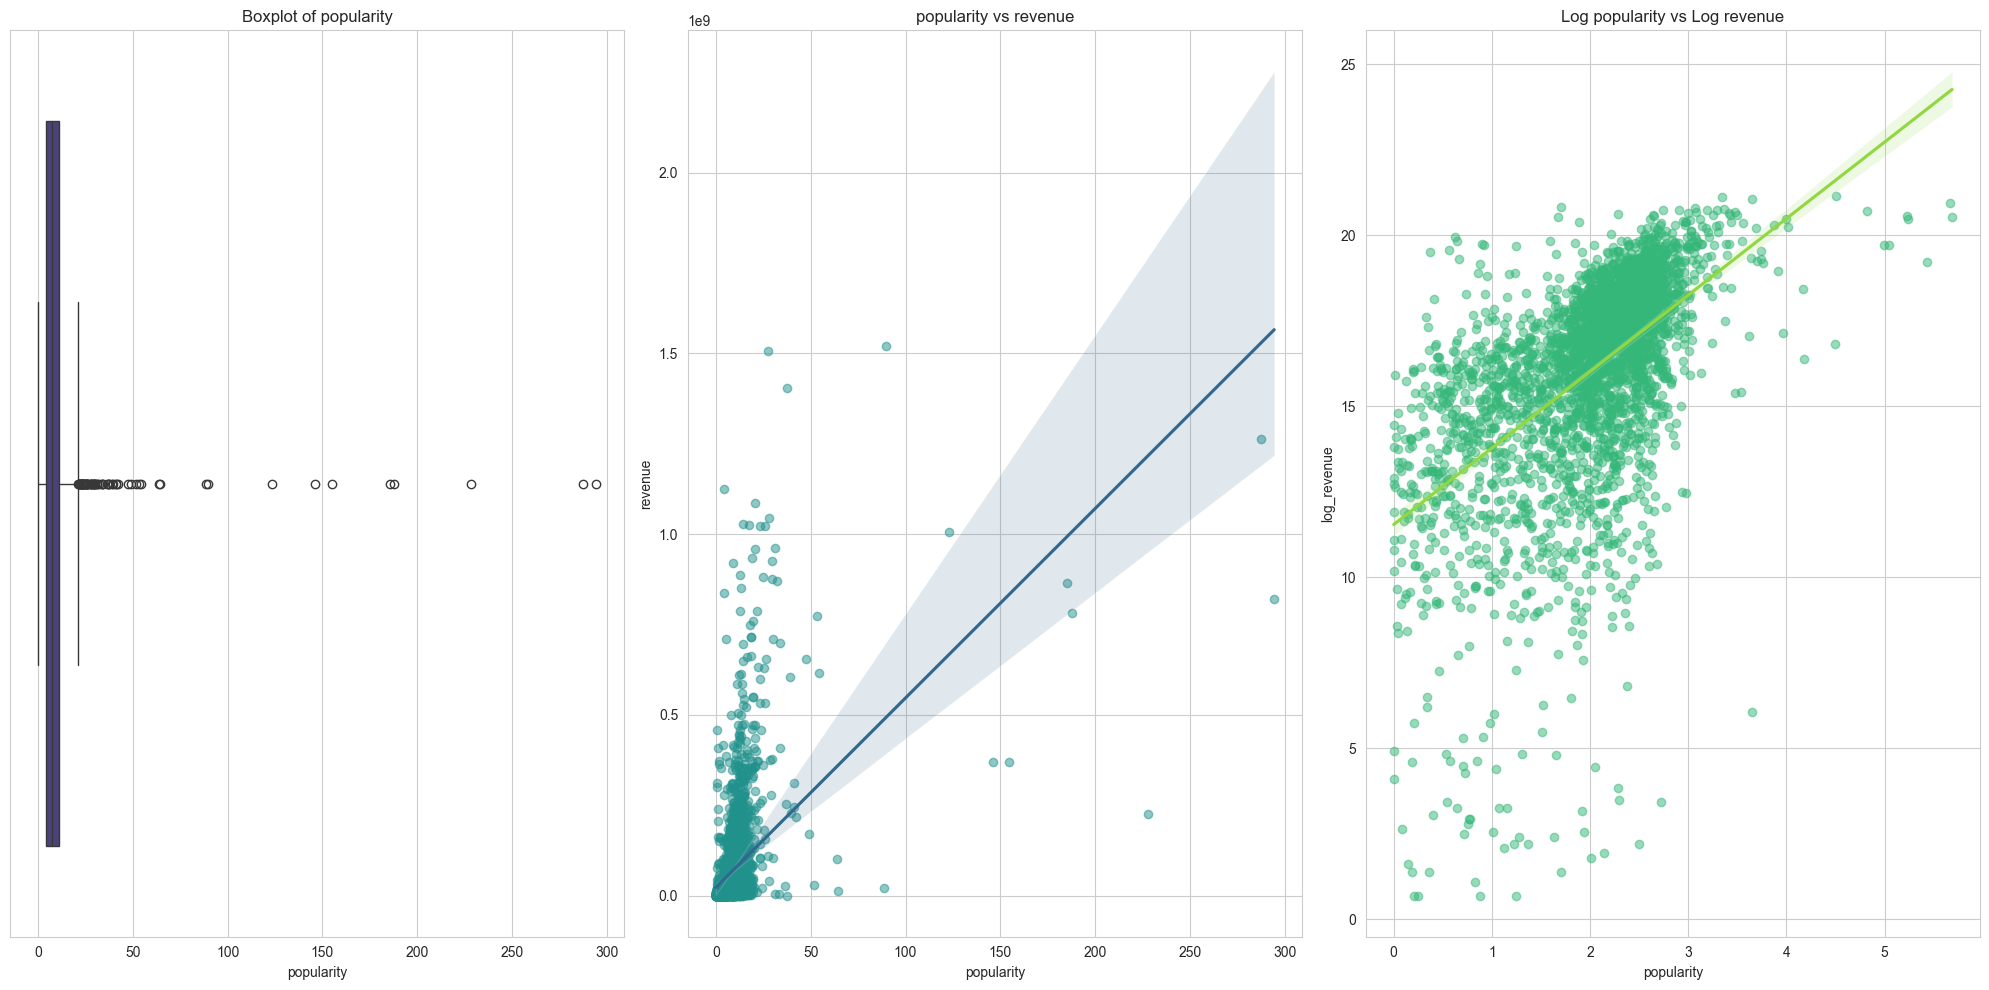

In [19]:
compare_feature_with_revenue(train, 'popularity')

- **Boxplot of Popularity**: The popularity distribution is strongly right-skewed, with most movies having relatively low popularity and several extreme outliers with very high values.
- **Popularity vs Revenue**: There is a positive relationship between popularity and revenue, although the dispersion is large, indicating that highly popular movies tend to earn more but with considerable variability.
- **Log Popularity vs Log Revenue**: After applying the logarithmic transformation, the relationship becomes more linear and clearer, suggesting that popularity is a useful predictor of revenue and that the log transformation helps stabilize the variance.

### 2.14 Belongs To Collection

Number of distinct Collections: 422


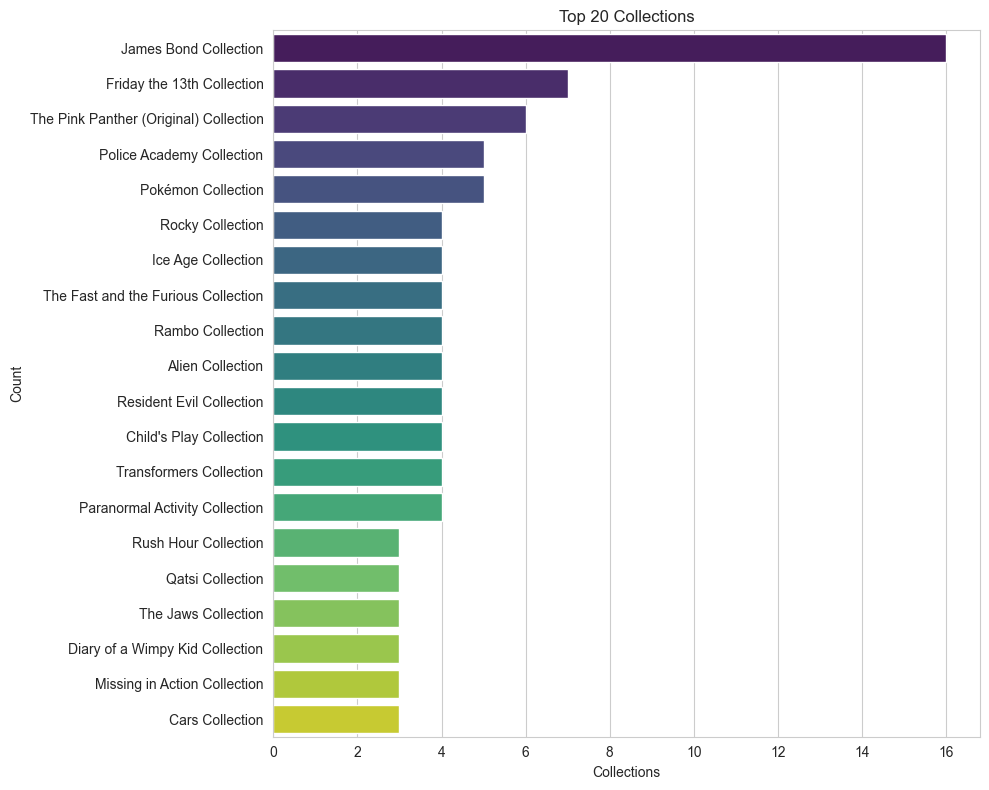

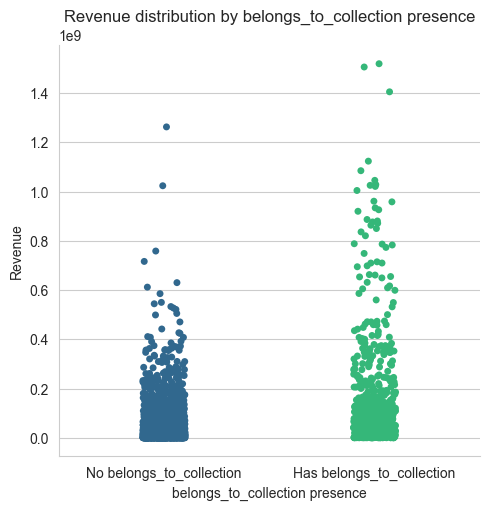

In [20]:
display_multilabels_feature_distribution(train, 'belongs_to_collection', 20, 'Collections')

collections_analysis = train.copy()
collections_analysis['belongs_to_collection'] = collections_analysis['belongs_to_collection'].apply(
    lambda x: 1 if len(x) > 0 else np.nan
)
display_feature_revenue_catplot(collections_analysis, 'belongs_to_collection')

The plot shows that movies belonging to a collection tend to generate higher revenues compared to standalone films. While movies without a collection are mostly concentrated at lower revenue levels, films that are part of a collection exhibit a wider distribution and include many of the highest-grossing titles. This suggests that franchises or sequels are often associated with greater commercial success.

### 2.15 Original Language

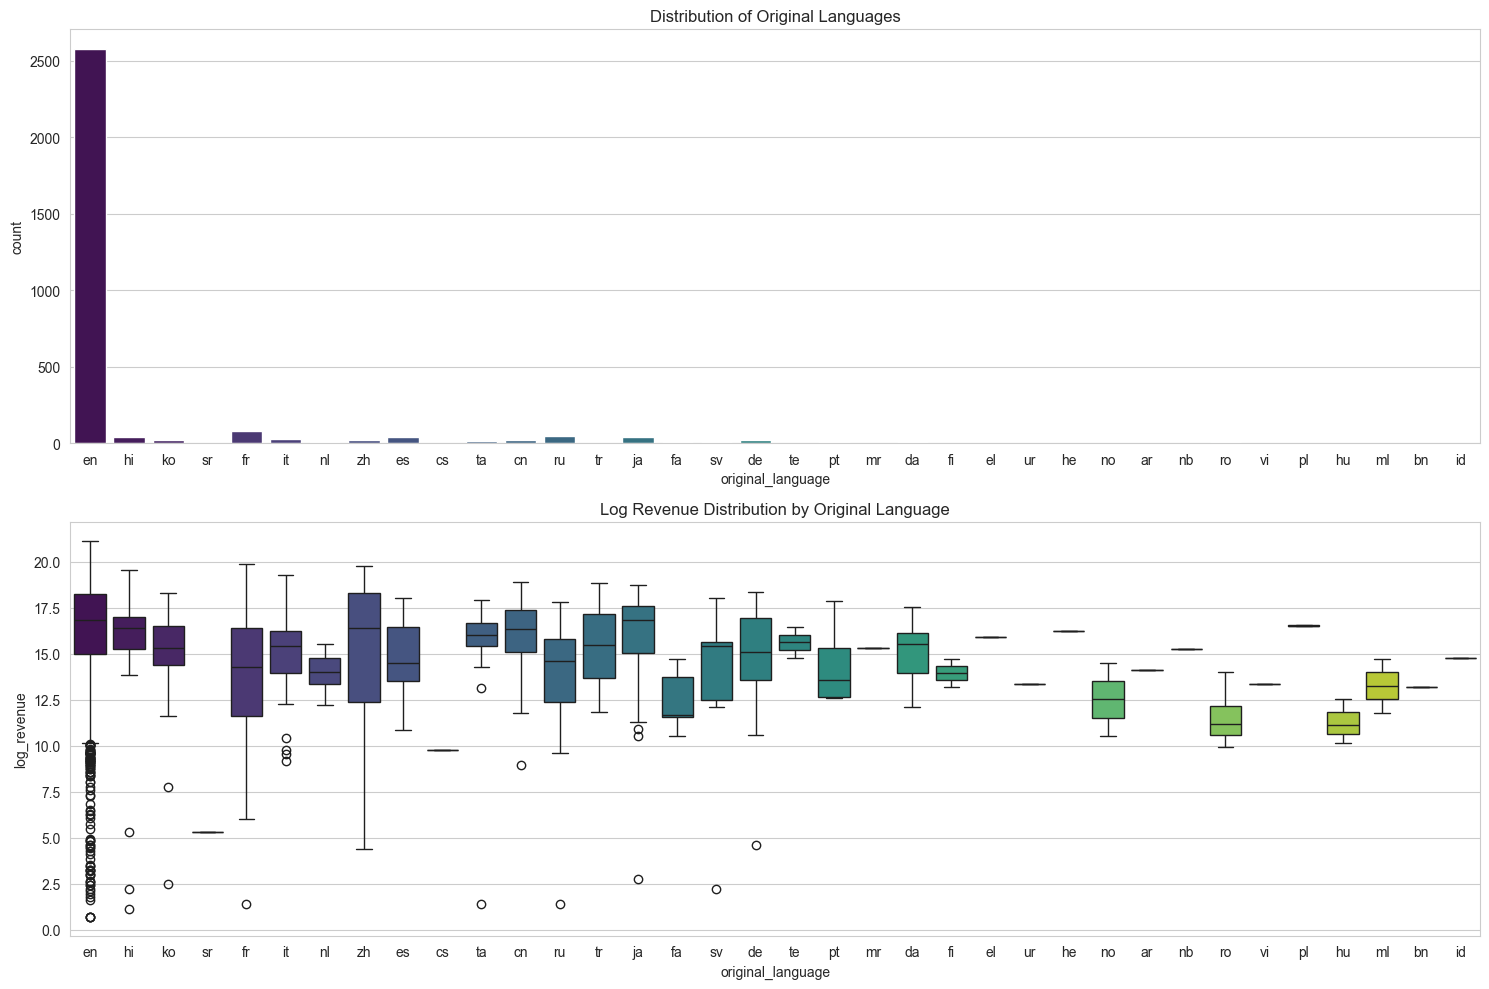

In [21]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 1, 1)
plt.title("Distribution of Original Languages")
sns.countplot(x='original_language', data=train, palette='viridis', hue='original_language', legend=False)

plt.subplot(2, 1, 2)
plt.title("Log Revenue Distribution by Original Language")
sns.boxplot(x='original_language', y='log_revenue', data=train, palette='viridis', hue='original_language', legend=False)

plt.tight_layout()
plt.show()

The plot suggests that original language may affect the revenue, with english movies showing higher medians and much greater variability. Other languages generally exhibit lower and more concentrated revenue distributions, likely reflecting more localized markets.